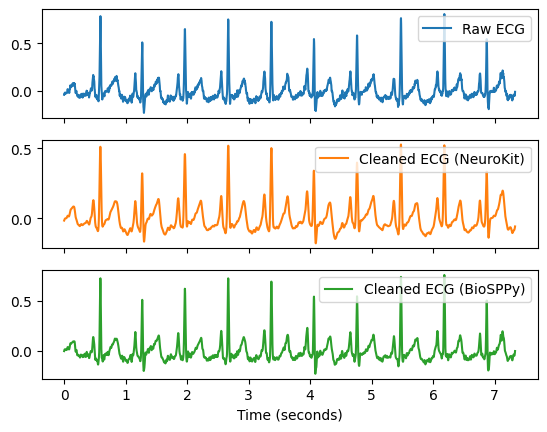

In [4]:
import wfdb
import neurokit2 as nk

# Replace with your local WFDB base path (without extension)
record_path = "/home/flo178/projects/master-thesis/datasets/physionet2025/sami-trop/processed/23710"
# record_path = "/home/flo178/projects/master-thesis/datasets/physionet2025/code15/processed/exams_part4/14105"
# record_path = "/home/flo178/projects/master-thesis/datasets/physionet2025/ptb-xl/records500/00000/00069_hr"


# Load signal and metadata
signals, info = wfdb.rdsamp(record_path)
fs = info["fs"]

# Use the first channel (adjust if needed)
ecg = signals[:, 0]

# Clean the ECG
ecg_cleaned_nk = nk.ecg_clean(
    ecg,
    sampling_rate=fs,
    method="neurokit",)
ecg_cleaned_biosppy = nk.ecg_clean(
    ecg,
    sampling_rate=fs,
    method="biosppy",
)
# Plot raw and cleaned ECG signals
nk.signal_plot(
    signal=[ecg,ecg_cleaned_nk, ecg_cleaned_biosppy],
    sampling_rate=fs,
    subplots=True,
    labels=["Raw ECG", "Cleaned ECG (NeuroKit)", "Cleaned ECG (BioSPPy)"])

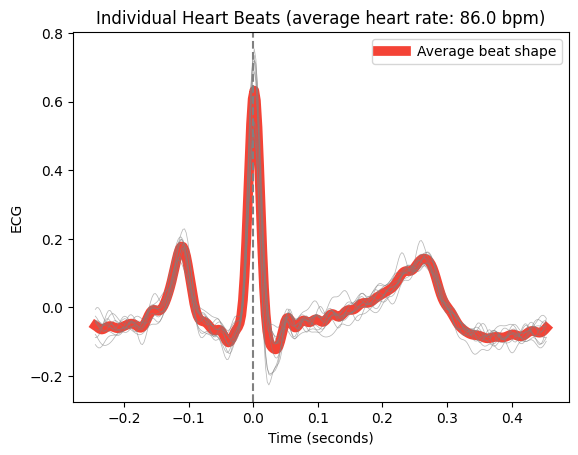

In [5]:
# Plotting all the heart beats
epochs = nk.ecg_segment(ecg_cleaned_biosppy, rpeaks=None, sampling_rate=fs, show=True)


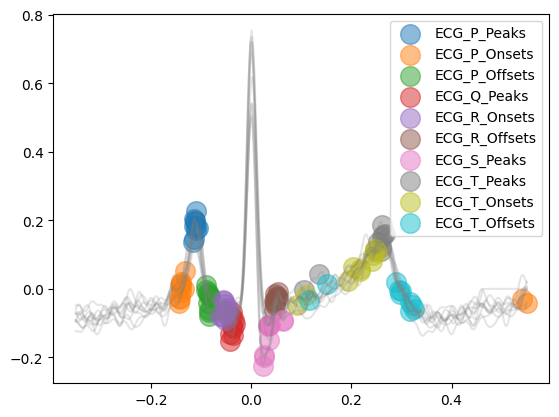

In [6]:
_, rpeaks = nk.ecg_peaks(ecg_cleaned_biosppy, sampling_rate=fs)
# Delineate the ECG signal and visualizing all peaks of ECG complexes
_, waves_peak = nk.ecg_delineate(
    ecg_cleaned_biosppy,
    rpeaks,
    sampling_rate=fs,
    method="dwt",
    show=True,
    show_type="all",
)
